# **Data Analysis**

In [141]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
df = pd.read_csv("/content/drive/MyDrive/BRACU 8th Semester/CSE422_LAB/CSE422 Project/2.csv")

In [144]:
print("Dataset Shape:", df.shape)
print()

print("Missing Values:")
print()
print(df.isnull().sum())
print()

print("Descriptive Statistics:")
print()

print(df.describe())
print()

print("Target Variable Distribution:")
print()
print(df['Quality_Label'].value_counts())

Dataset Shape: (1600, 9)

Missing Values:

Lines_of_Code            80
Cyclomatic_Complexity     0
Num_Functions             0
Code_Churn               80
Comment_Density          80
Num_Bugs                  0
Has_Unit_Tests            0
Code_Owner_Experience     0
Quality_Label             0
dtype: int64

Descriptive Statistics:

       Lines_of_Code  Cyclomatic_Complexity  Num_Functions   Code_Churn  \
count    1520.000000            1600.000000    1600.000000  1520.000000   
mean     4939.269737              25.076875     103.178125   102.572291   
std      2867.248259              13.879621      55.503710    50.546329   
min       106.000000               1.000000       5.000000   -64.283310   
25%      2490.750000              13.000000      56.000000    67.509852   
50%      4860.000000              25.000000     104.000000   104.007452   
75%      7455.250000              37.000000     152.000000   138.619113   
max      9998.000000              49.000000     199.000000   295.1

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

In [146]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [147]:
sns.set_style("whitegrid")

Exploratory Data Analysis (EDA)



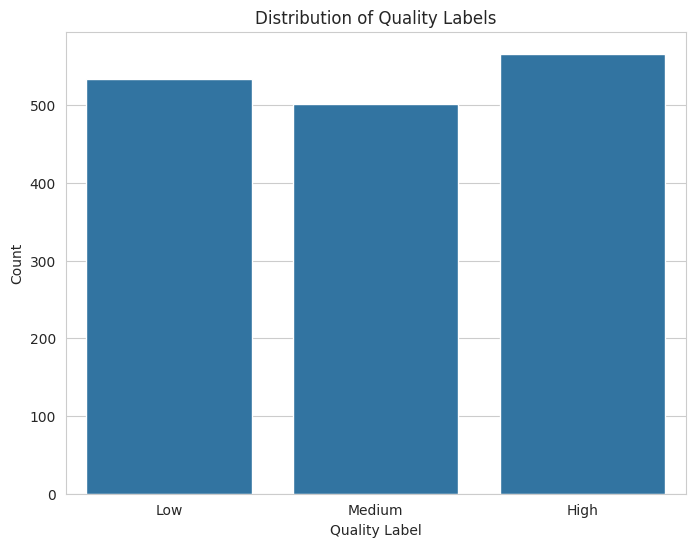

In [148]:
print("Exploratory Data Analysis (EDA)")
print()

# Distribution of the target variable

plt.figure(figsize=(8, 6))
sns.countplot(x='Quality_Label', data=df, order=['Low', 'Medium', 'High'])
plt.title('Distribution of Quality Labels')
plt.ylabel('Count')
plt.xlabel('Quality Label')
plt.show()

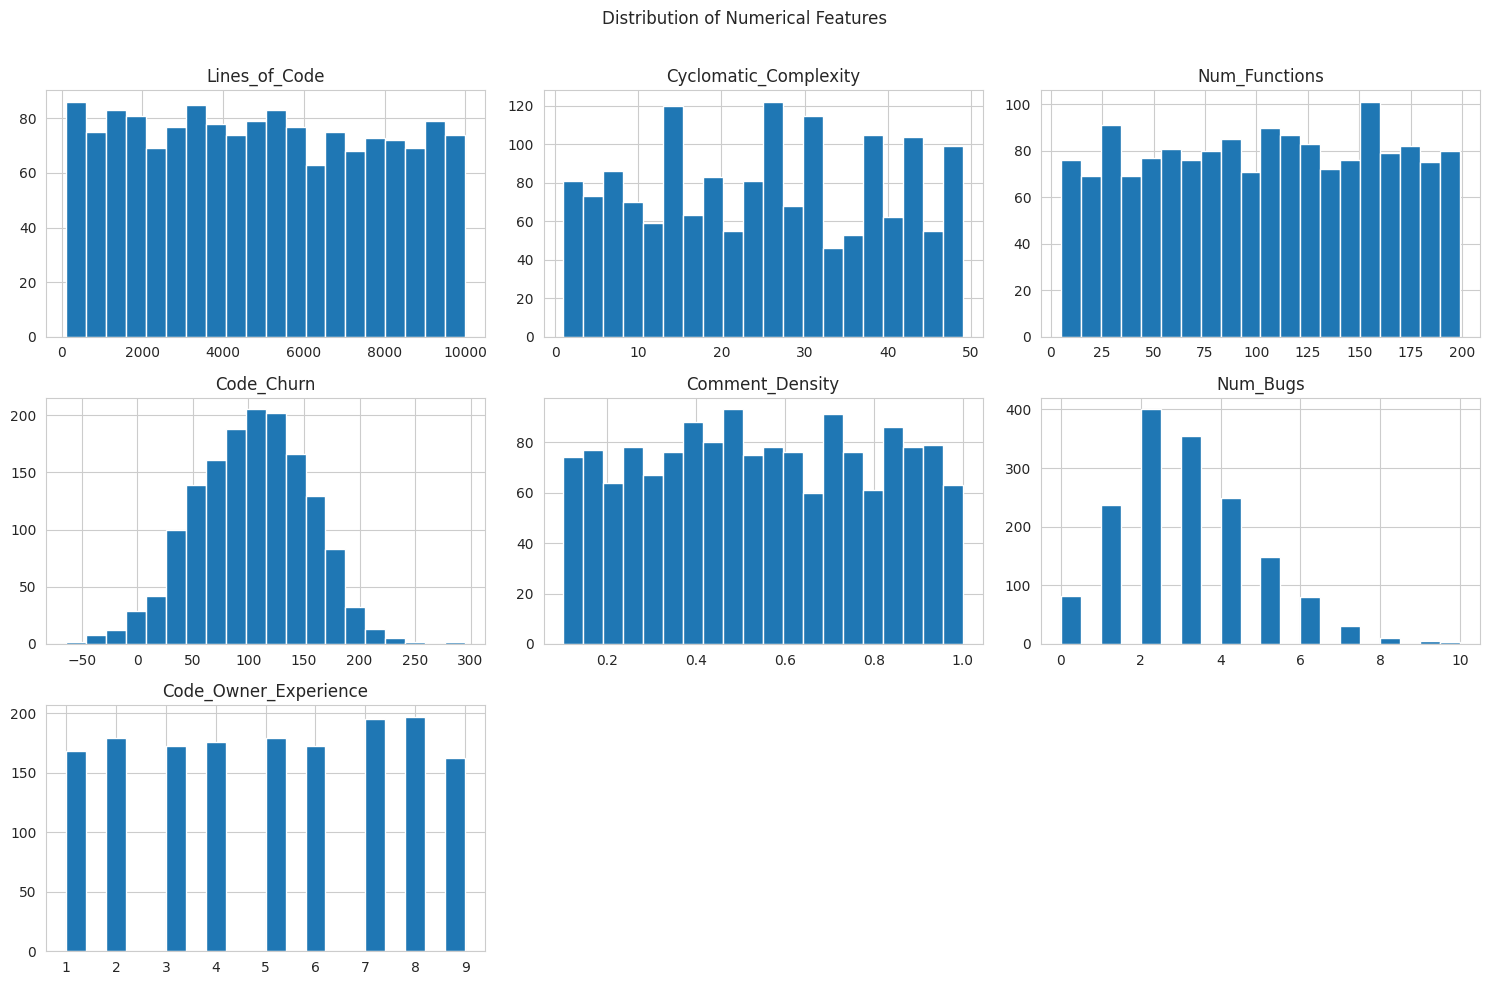

In [149]:
# Histograms for numerical features

numerical_features = df.select_dtypes(include=np.number).columns
df[numerical_features].hist(bins=20, figsize=(15, 10), layout=(3, 3))
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

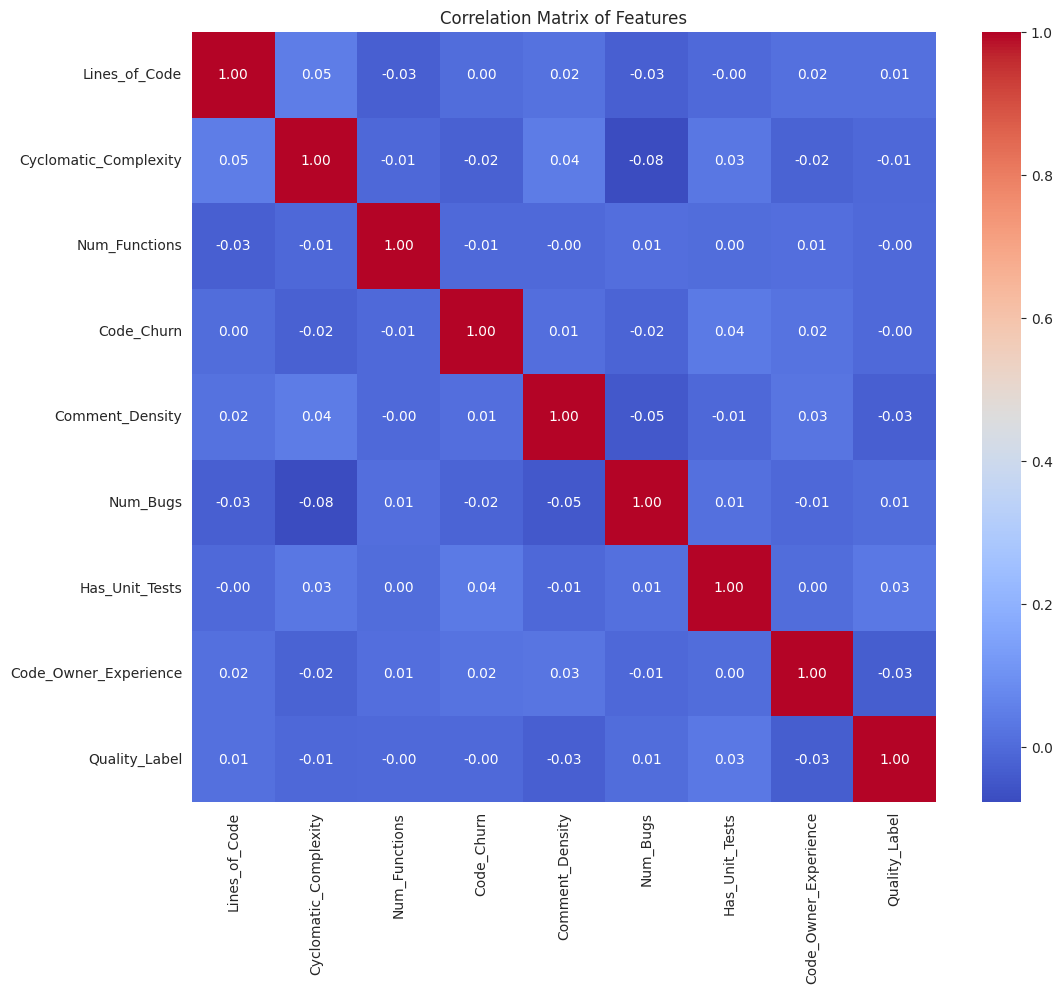

In [150]:
# Correlation Matrix

# Created a copy here for encoding ---> to avoid changing the original df prematurely

df_corr = df.copy()

# Temporarily encoded categorical features for correlation calculation

if df_corr['Has_Unit_Tests'].dtype == 'object':
    df_corr['Has_Unit_Tests'] = df_corr['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})

if df_corr['Quality_Label'].dtype == 'object':
    quality_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Quality_Label'] = df_corr['Quality_Label'].map(quality_mapping)

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

#**Dataset Pre-processing**



```
--------------> Handling Null and Duplicate Values
```



In [151]:
# Fixing the Negative Code_Churn values by taking the absolute value

df['Code_Churn'] = df['Code_Churn'].abs()

In [152]:
# Handling Null Values

# ---> Null values handled by imputing with the median

print(df.isnull().sum())

# imputer = SimpleImputer(strategy='median')
# num_cols_with_nulls = ['Lines_of_Code', 'Code_Churn', 'Comment_Density']
# df[num_cols_with_nulls] = imputer.fit_transform(df[num_cols_with_nulls])


##  test

group_medians = df.groupby('Quality_Label')['Comment_Density'].transform(lambda x: x.mode('mode')[0])
df['Comment_Density'] = df['Comment_Density'].fillna(group_medians)


##

imputer = SimpleImputer(strategy='most_frequent')
num_cols_with_nulls = ['Lines_of_Code', 'Code_Churn', 'Comment_Density']
df[num_cols_with_nulls] = imputer.fit_transform(df[num_cols_with_nulls])

Lines_of_Code            80
Cyclomatic_Complexity     0
Num_Functions             0
Code_Churn               80
Comment_Density          80
Num_Bugs                  0
Has_Unit_Tests            0
Code_Owner_Experience     0
Quality_Label             0
dtype: int64


Handling outliers using Winsorizing...
Outlier handling complete.


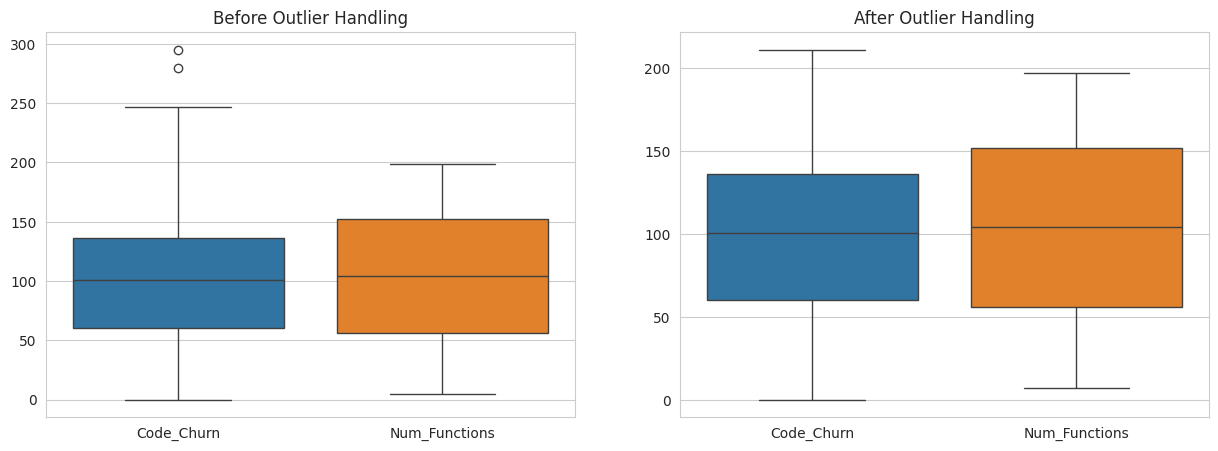

In [153]:
# Outlier handler

from scipy.stats.mstats import winsorize

print("Handling outliers using Winsorizing...")

df_before_outliers = df.copy()

columns_to_winsorize = ['Code_Churn', 'Num_Functions']

for col in columns_to_winsorize:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

print("Outlier handling complete.")

plt.figure(figsize=(15, 5))

# Before
plt.subplot(1, 2, 1)
sns.boxplot(data=df_before_outliers[columns_to_winsorize])
plt.title("Before Outlier Handling")

# After
plt.subplot(1, 2, 2)
sns.boxplot(data=df[columns_to_winsorize])
plt.title("After Outlier Handling")

plt.show()

In [154]:
# Checking For Duplicate Values

print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0




```
--------------> Encoding categorical values
```








In [155]:
# 1) For (Has_Unit_Test)
# ---> Mapping for binary feature

df['Has_Unit_Tests'] = df['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})
print("'Has_Unit_Tests' has been encoded (Yes: 1, No: 0).")
print()


# 2) For (Target variable - 'Quality_Label') ----> [LabelEncoder]

#  ---> Mapping: Low -> 0, Medium -> 1, High -> 2

le = LabelEncoder()
df['Quality_Label'] = le.fit_transform(df['Quality_Label'])

print("'Quality_Label' has been encoded:", {i: label for i, label in enumerate(le.classes_)})

'Has_Unit_Tests' has been encoded (Yes: 1, No: 0).

'Quality_Label' has been encoded: {0: 'High', 1: 'Low', 2: 'Medium'}





```
--------------> Feature scaling
```



In [156]:
# We have applied [Standardization (Z-score normalization)]

X = df.drop('Quality_Label', axis=1)
y = df['Quality_Label']



```
--------------> Data Split
```



In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled using StandardScaler.")

Features have been scaled using StandardScaler.




```
--------------> Removing irrelevant features
```


> For this project, we will retain all features as the correlation matrix did not show any with zero correlation to the target.
> No additional feature engineering was deemed necessary at this stage.



# **Model Training (Supervised)**



```
--------------> a) Neural Network (using TensorFlow)
```



In [158]:
print("Training a Neural Network...\n")

# One-hot encode the target variable for the neural network

y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

nn_model = Sequential([Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
                       Dropout(0.3),
                       Dense(32, activation='relu'),
                       Dropout(0.3),
                       Dense(3, activation='softmax')]) # 3 output neurons for 3 classes

nn_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history = nn_model.fit(X_train_scaled, y_train_nn,
                       epochs=50,
                       batch_size=32,
                       validation_split=0.1,
                       verbose=0) # verbose = 0 for cleaner output

print("Neural Network training complete.")

Training a Neural Network...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network training complete.




```
--------------> b) K-Nearest Neighbors (KNN)
```



In [159]:
print("Training K-Nearest Neighbors (KNN)...\n")

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

print("KNN training complete.")

Training K-Nearest Neighbors (KNN)...

KNN training complete.





```
--------------> c) Decision Tree
```




In [160]:
print("Training Decision Tree...\n")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree training complete.")

Training Decision Tree...

Decision Tree training complete.




```
--------------> d) Random Forest
```



In [161]:
print("Training Random Forest...\n")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest training complete.")

Training Random Forest...

Random Forest training complete.


# **Model Training (Unsupervised)**


```
--------------> Unsupervised
```



```
--------------> d) K-Means Clustering
```



Generating Elbow Method Plot...



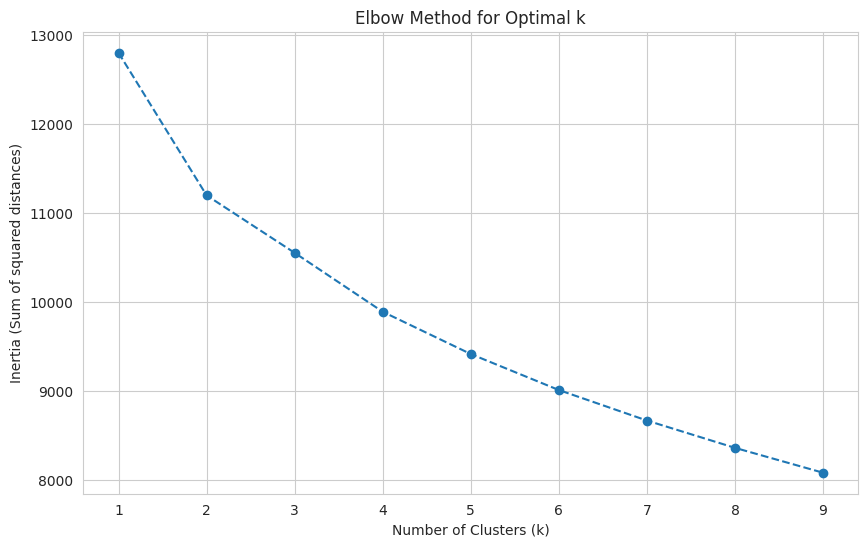

Elbow Method Plot generated.

Generating K-Means Cluster Visualization using PCA...


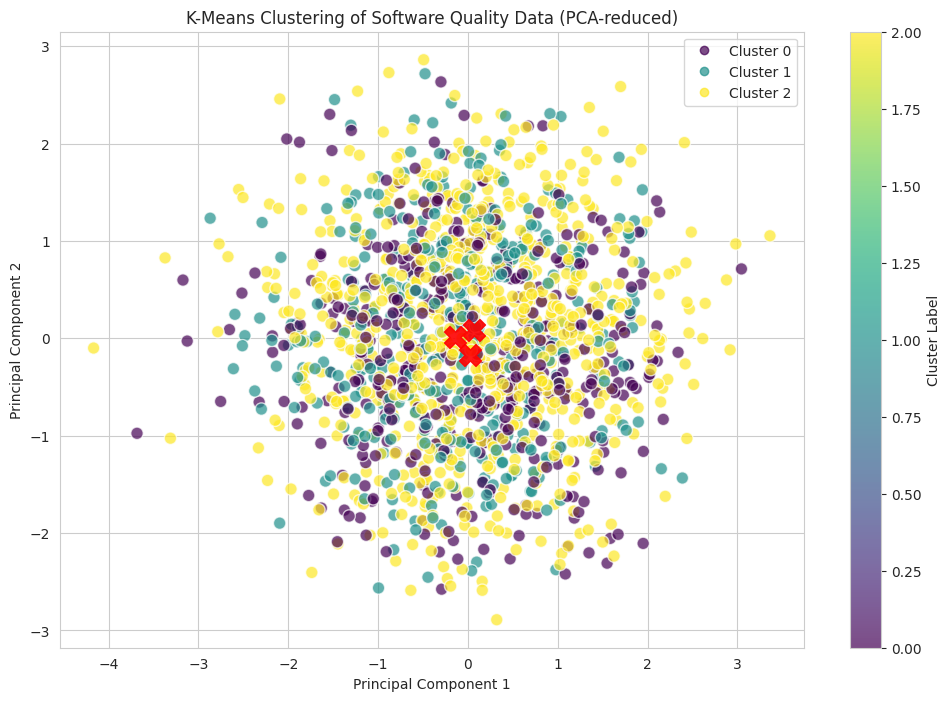

Cluster visualization generated.


In [162]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df.drop('Quality_Label', axis=1)

if 'Has_Unit_Tests' in X.columns and X['Has_Unit_Tests'].dtype == 'object':
    X['Has_Unit_Tests'] = X['Has_Unit_Tests'].map({'Yes': 1, 'No': 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("Generating Elbow Method Plot...\n")

inertia = []   # An array where we are storing error list
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()
print("Elbow Method Plot generated.\n")


print("Generating K-Means Cluster Visualization using PCA...")
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)



pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='w', s=80)

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, alpha=0.9, marker='X', label='Cluster Centers')

plt.title('K-Means Clustering of Software Quality Data (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(n_clusters)])
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()
print("Cluster visualization generated.")

In [163]:
print("Applying K-Means Clustering (Unsupervised)...\n")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

cluster_comparison = pd.crosstab(y_train, kmeans.labels_) # We can analyze the clusters, by comparing them to the true labelss

print("K-Means clustering applied.")
print("Here is a comparison of true labels vs cluster labels:\n")
print(cluster_comparison)

Applying K-Means Clustering (Unsupervised)...

K-Means clustering applied.
Here is a comparison of true labels vs cluster labels:

col_0            0    1    2
Quality_Label               
0              104  204  201
1               94  182  204
2               93  167  191


# **Model Evaluation**



```
--------------> Supervised

```



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


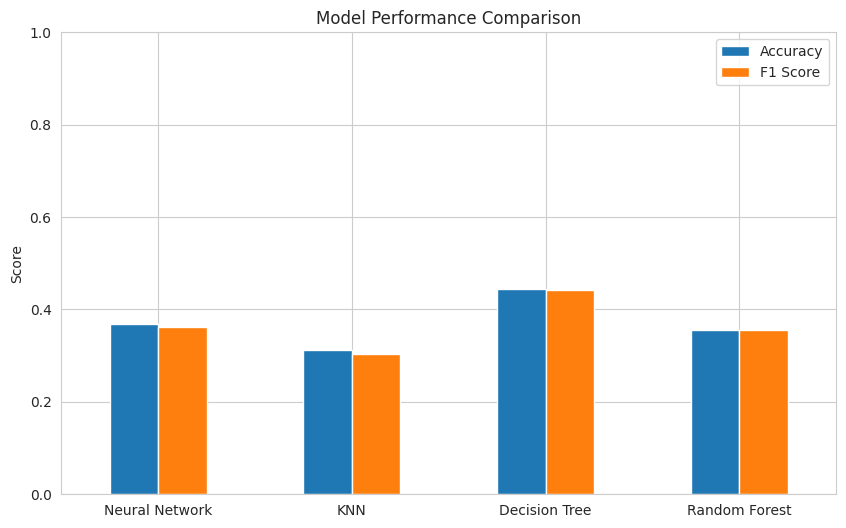

In [164]:
# Neural Network predictions
y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

# KNN predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Decision Tree predictions
y_pred_dt = dt_model.predict(X_test_scaled)


# Random Forest predictions
y_pred_rf = rf_model.predict(X_test_scaled)

models = {'Neural Network': y_pred_nn,
          'KNN': y_pred_knn,
          'Decision Tree': y_pred_dt,
          'Random Forest': y_pred_rf}

accuracies = {}
f1_scores = {}

for name, y_pred in models.items():
    accuracies[name] = accuracy_score(y_test, y_pred)
    f1_scores[name] = f1_score(y_test, y_pred, average='weighted')

##############################################################################

# Bar chart showcasing prediction accuracy and f1 score

metrics_df = pd.DataFrame({'Accuracy': accuracies, 'F1 Score': f1_scores})
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation = 0)
plt.ylim(0, 1)
plt.show()

----> Performance Metrics for Neural Network <----

              precision    recall  f1-score   support

        High       0.39      0.51      0.44        57
         Low       0.32      0.25      0.28        53
      Medium       0.38      0.34      0.36        50

    accuracy                           0.37       160
   macro avg       0.36      0.36      0.36       160
weighted avg       0.36      0.37      0.36       160



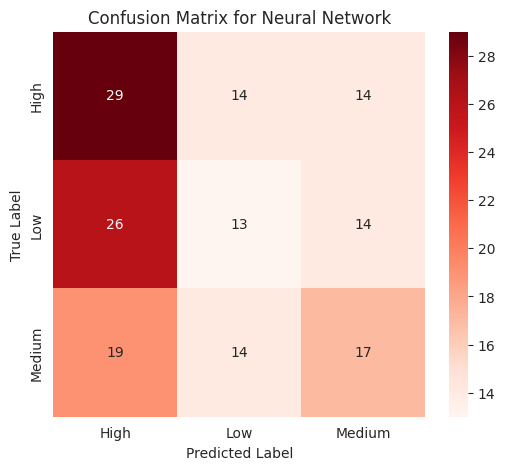


----> Performance Metrics for KNN <----

              precision    recall  f1-score   support

        High       0.36      0.44      0.39        57
         Low       0.32      0.32      0.32        53
      Medium       0.22      0.16      0.18        50

    accuracy                           0.31       160
   macro avg       0.30      0.31      0.30       160
weighted avg       0.30      0.31      0.30       160



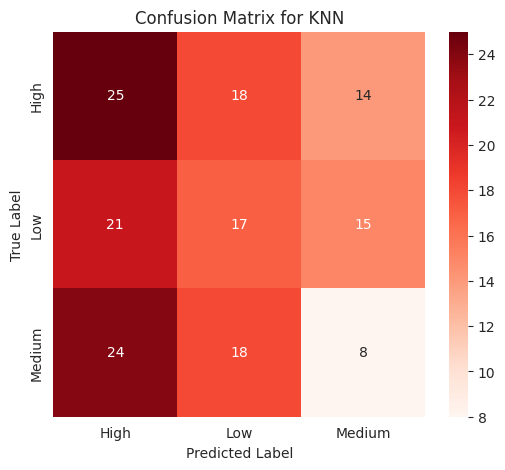


----> Performance Metrics for Decision Tree <----

              precision    recall  f1-score   support

        High       0.46      0.44      0.45        57
         Low       0.47      0.53      0.50        53
      Medium       0.39      0.36      0.38        50

    accuracy                           0.44       160
   macro avg       0.44      0.44      0.44       160
weighted avg       0.44      0.44      0.44       160



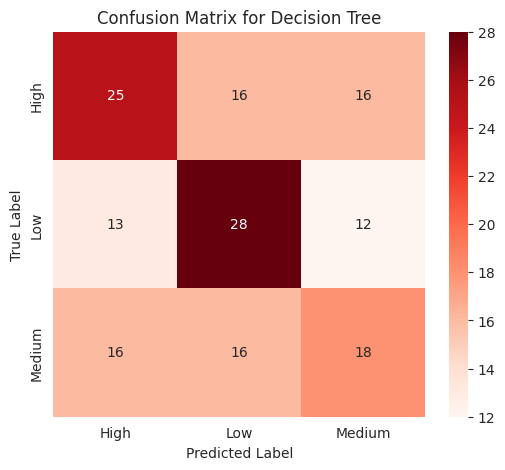


----> Performance Metrics for Random Forest <----

              precision    recall  f1-score   support

        High       0.34      0.42      0.38        57
         Low       0.36      0.30      0.33        53
      Medium       0.38      0.34      0.36        50

    accuracy                           0.36       160
   macro avg       0.36      0.35      0.35       160
weighted avg       0.36      0.36      0.35       160



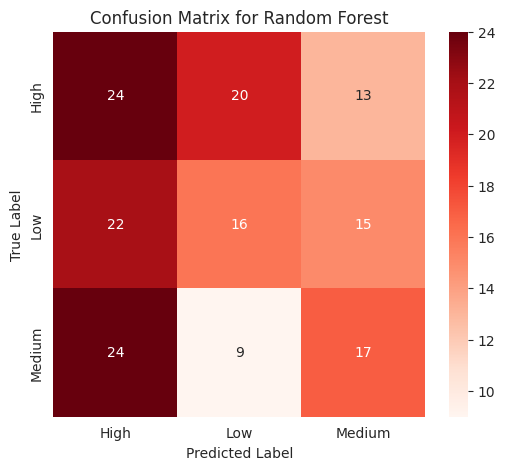

In [165]:
# Performance metrics comparison and Confusion Matrix for each model

for name, y_pred in models.items():
    print(f"----> Performance Metrics for {name} <----")
    print()
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print()



```
--------------> AUC score and ROC curve
```



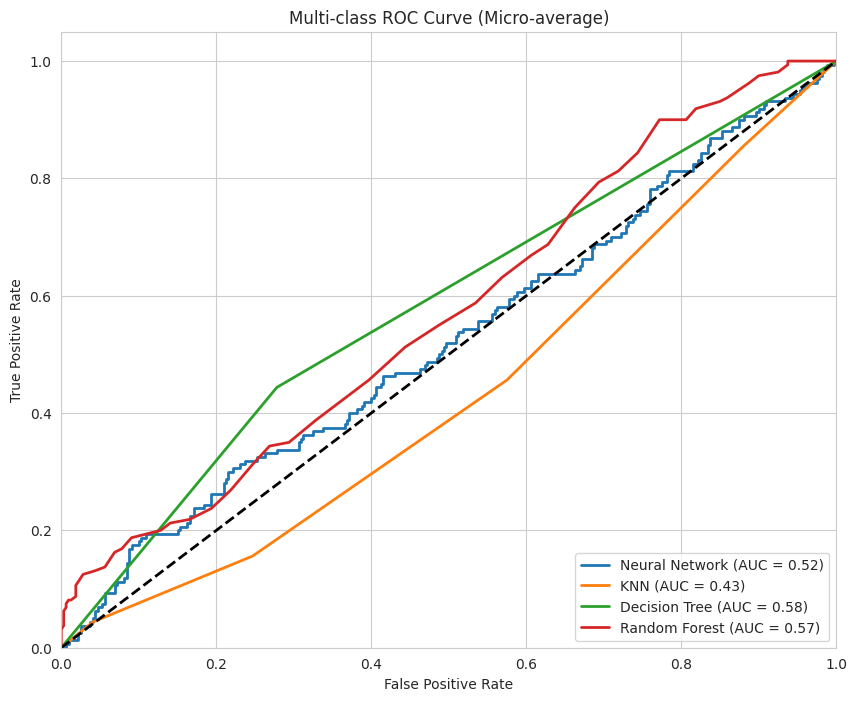

In [166]:
# Binarizing the output here

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Probabilities for ROC curve

y_prob_knn = knn_model.predict_proba(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)
# NN probabilities = y_pred_nn_prob

model_probs = {'Neural Network': y_pred_nn_prob,
               'KNN': y_prob_knn,
               'Decision Tree': y_prob_dt,
               'Random Forest': y_prob_rf}

plt.figure(figsize=(10, 8))

# ROC curve and ROC area for each class

for name, y_prob in model_probs.items():

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-Average ROC Curve and ROC Area

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], lw=2, label=f'{name} (AUC = {roc_auc["micro"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (Micro-average)')
plt.legend(loc="lower right")
plt.show()

# Conclusion

In [167]:
best_model = max(f1_scores, key=f1_scores.get)

print(f"The best model based on the model evaluation (weighted F1-score) is: {best_model} with a score of {f1_scores[best_model]:.4f}.")

The best model based on the model evaluation (weighted F1-score) is: Decision Tree with a score of 0.4418.
